# Second-order convergence test

In [1]:
import numpy as np
from matplotlib.pyplot import *
import pyhelmholtz as ph
limits = [-1,1,-1,1]              # interior domain (m)
c = ph.LIGHT_SPEED                # wave speed in the domain
h_array = [0.004,0.005,0.01,0.02] # grid spacings for convergence test
f = 2e9                           # frequency of time-harmonic point source
wavelength = c/f
source = ph.PointSource(freq=f, xs=0, ys=0)

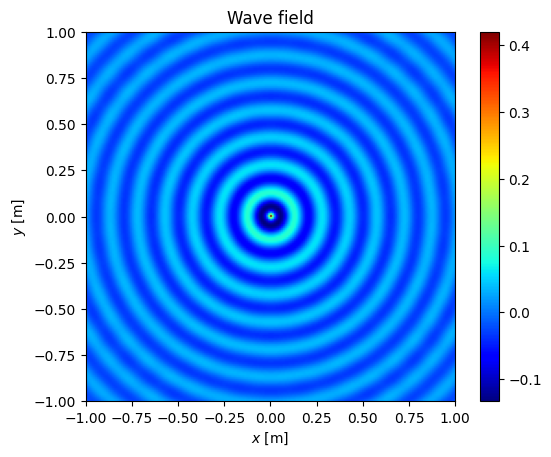

In [3]:
h = 0.01
domain = ph.Domain(h=h, limits=limits)
abm = ph.RenLiu("EM1")
ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(2))
ho.solve(solver="nested_dissection")
ho.viz()

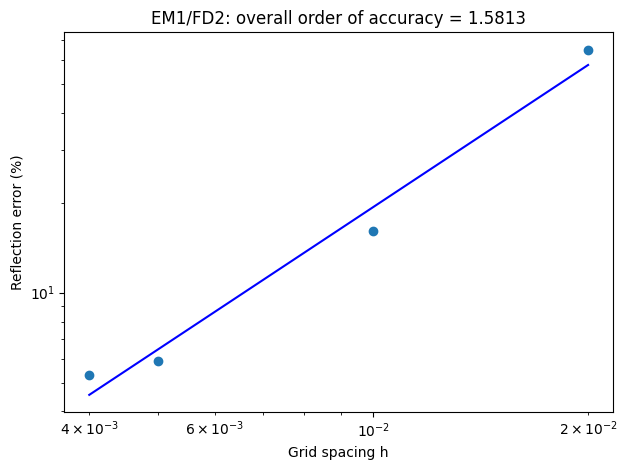

In [ ]:
# ABM = First-order Engquist-Majda ABC
# FD order = 2
# runtime (laptop) = 14 s
# runtime (ubuntu) = 9 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    abm = ph.RenLiu("EM1")
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(2))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()


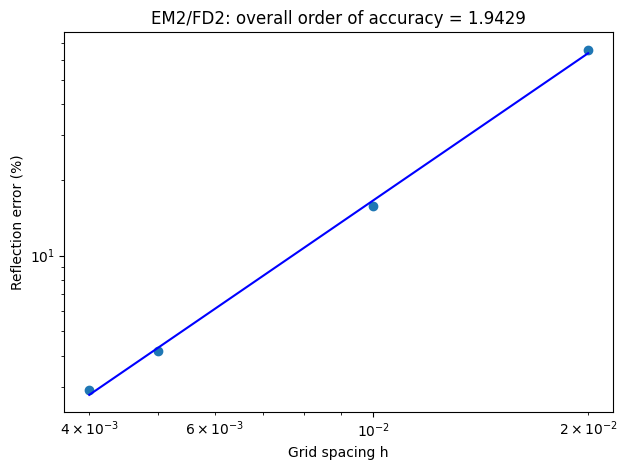

In [ ]:
# ABM = Second-order Engquist-Majda ABC
# FD order = 2
# runtime (laptop) = 14.4 s
# runtime (ubuntu) = 8.9 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    abm = ph.RenLiu("EM2")
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(2))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()


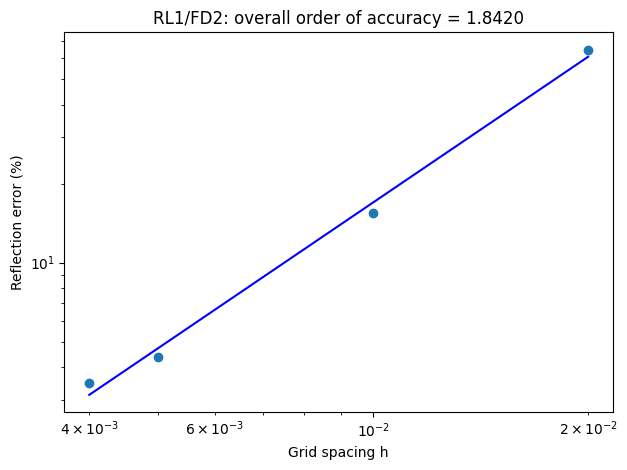

In [ ]:
# ABM = Ren-Liu hybrid ABC of first-order Engquist-Majda ABC
# thickness = one wavelength
# FD order = 2
# runtime (laptop) = 34.4 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = int(wavelength/h)
    abm = ph.RenLiu("RL1", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(2))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

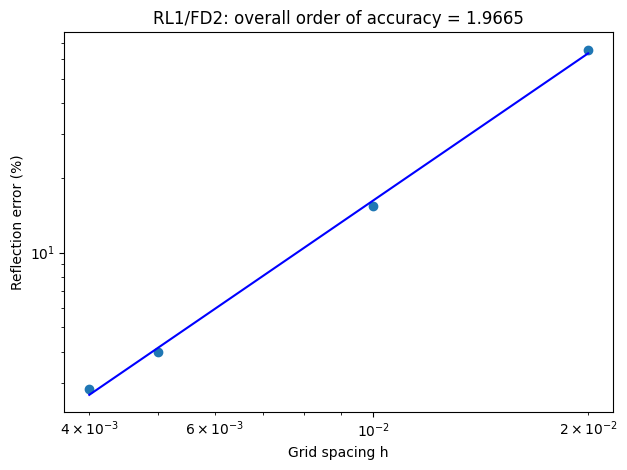

In [14]:
# ABM = Ren-Liu hybrid ABC of first-order Engquist-Majda ABC
# thickness = one and a half wavelength
# FD order = 2
# runtime (laptop) = 34.4 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = int(1.5*wavelength/h)
    abm = ph.RenLiu("RL1", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(2))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

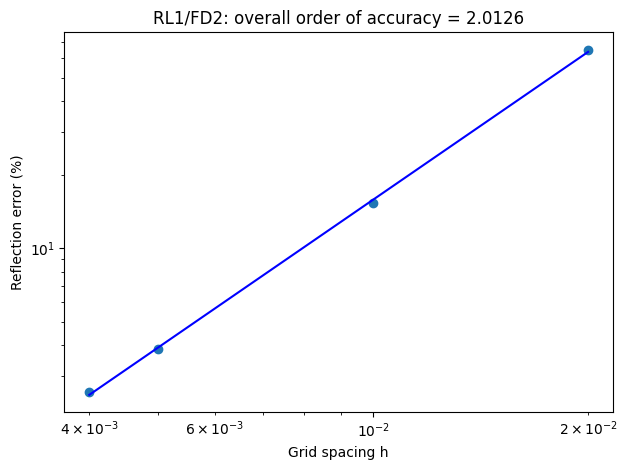

In [ ]:
# ABM = Ren-Liu hybrid ABC of first-order Engquist-Majda ABC
# thickness = two wavelengths
# FD order = 2
# runtime (laptop) = 1m 25.9 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = 2*int(wavelength/h)
    abm = ph.RenLiu("RL1", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(2))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

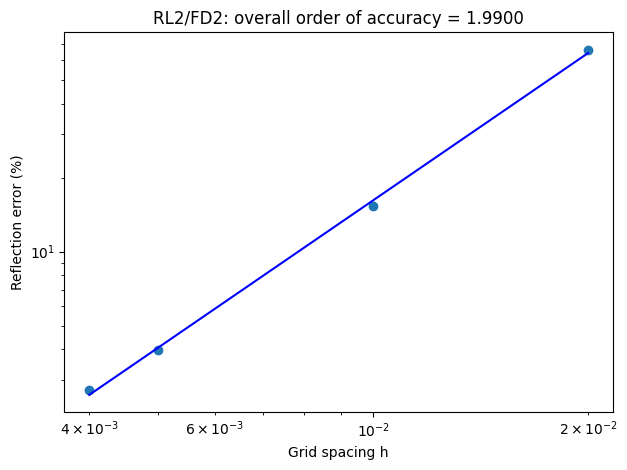

In [ ]:
# ABM = Ren-Liu hybrid ABC of second-order Engquist-Majda ABC
# thickness = 2 cells
# FD order = 2
# runtime (laptop) = 14.9 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = int(0.25*wavelength/h)
    abm = ph.RenLiu("RL2", n=2)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(2))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

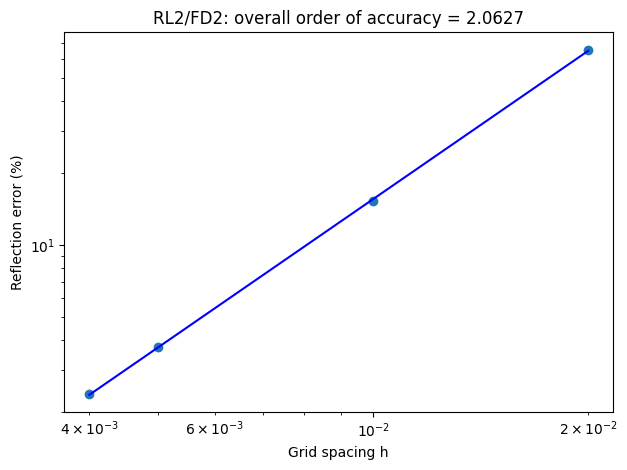

In [ ]:
# ABM = Ren-Liu hybrid ABC of second-order Engquist-Majda ABC
# thickness = a quarter wavelength
# FD order = 2
# runtime (laptop) = 18.9 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = int(0.25*wavelength/h)
    abm = ph.RenLiu("RL2", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(2))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

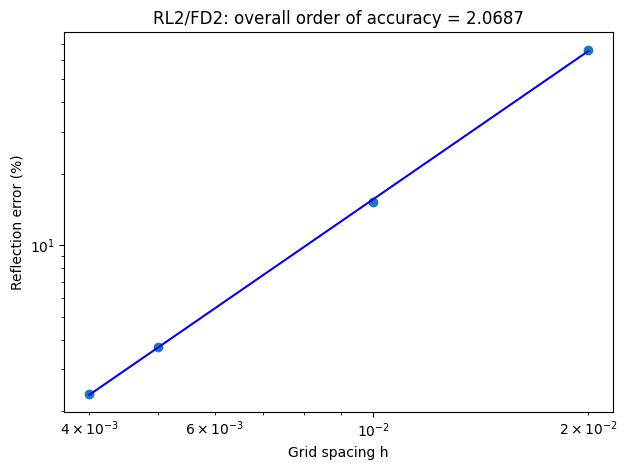

In [ ]:
# ABM = Ren-Liu hybrid ABC of second-order Engquist-Majda ABC
# thickness = half wavelength
# FD order = 2
# runtime (laptop) = 25.2 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = int(0.5*wavelength/h)
    abm = ph.RenLiu("RL2", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(2))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

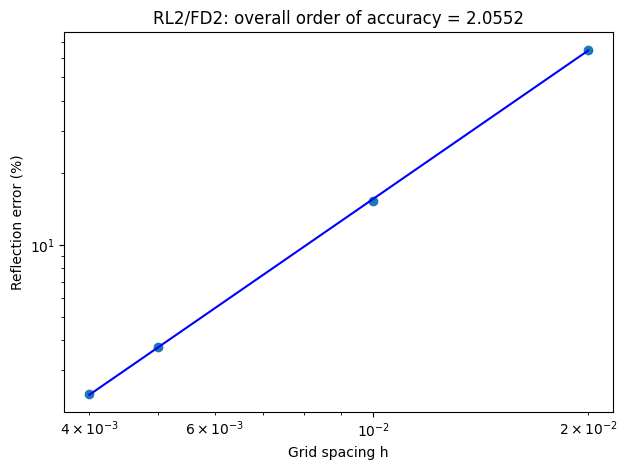

In [ ]:
# ABM = Ren-Liu hybrid ABC of second-order Engquist-Majda ABC
# FD order = 2
# runtime (laptop) = 49.8 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = int(wavelength/h)
    abm = ph.RenLiu("RL2", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(2))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

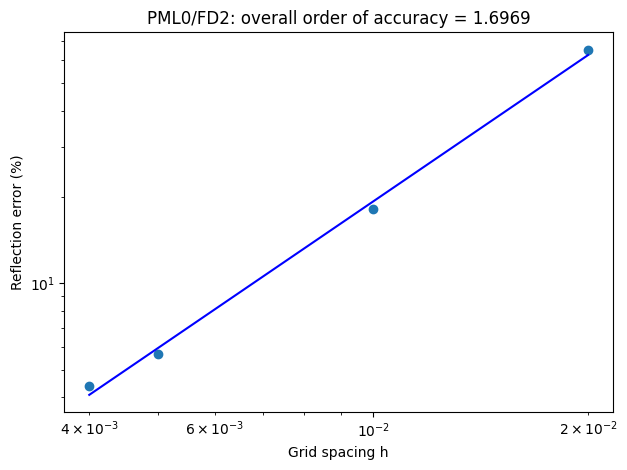

In [ ]:
# ABM = PML
# thickness = 2 cells
# FD order = 2
# runtime (laptop) = 19.6 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    abm = ph.PML("PML0", n=2)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(2))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

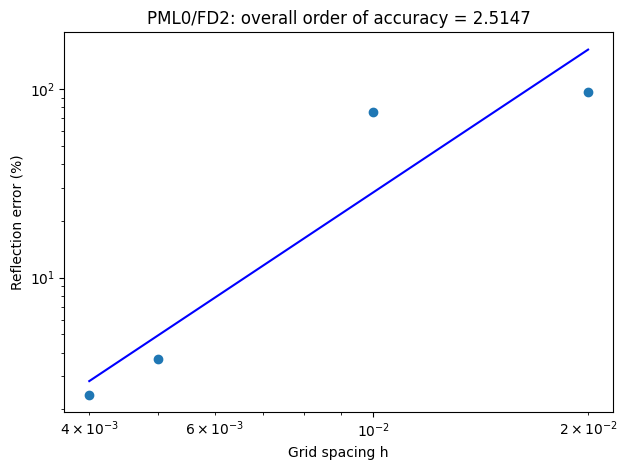

In [17]:
# ABM = PML
# thickness = wavelength/8
# FD order = 2
# runtime (ubuntu) = 21.7 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = max(1,int(0.125*wavelength/h))
    abm = ph.PML("PML0", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(2))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

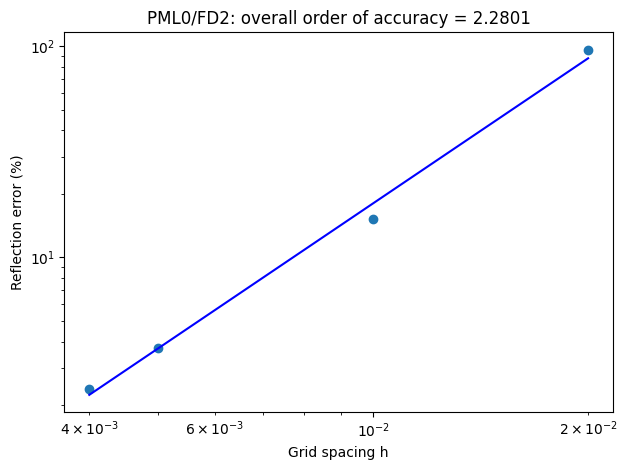

In [ ]:
# ABM = PML
# thickness = a quarter wavelength
# FD order = 2
# runtime (laptop) = 21.7 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = int(0.25*wavelength/h)
    abm = ph.PML("PML0", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(2))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

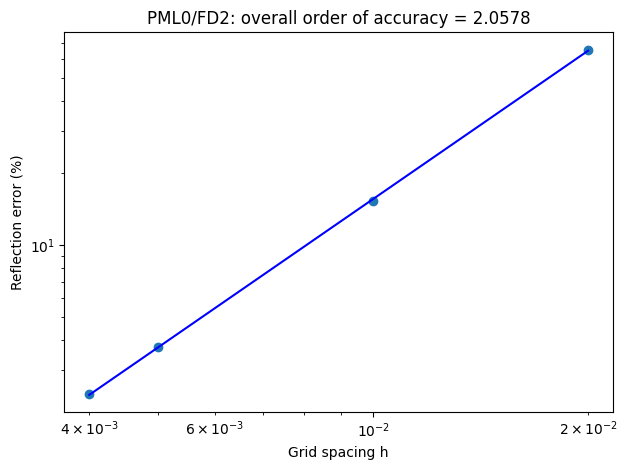

In [ ]:
# ABM = PML
# thickness = half wavelength
# FD order = 2
# runtime (laptop) = 28.1 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = int(0.5*wavelength/h)
    abm = ph.PML("PML0", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(2))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

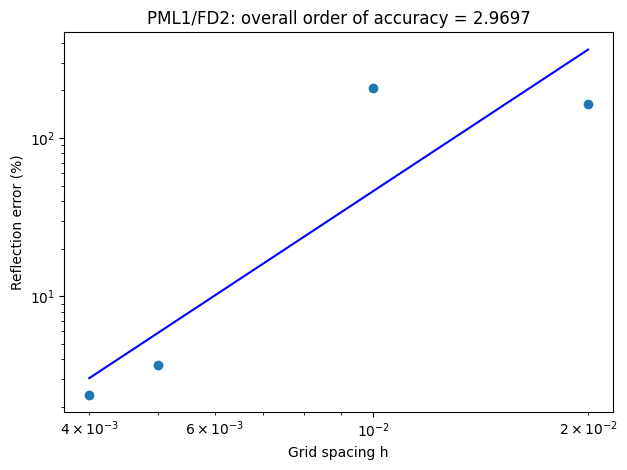

In [ ]:
# ABM = PML+EM1
# thickness = wavelength/8
# FD order = 2
# runtime (laptop) = 20.4 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = max(1,int(0.125*wavelength/h))
    abm = ph.PML("PML1", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(2))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

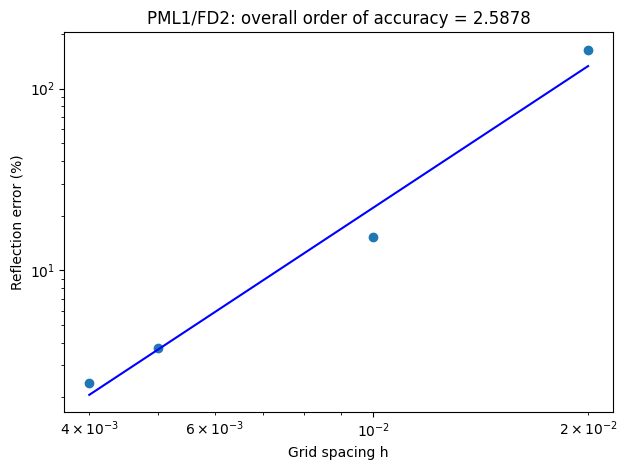

In [ ]:
# ABM = PML+EM1
# thickness = a quarter wavelength
# FD order = 2
# runtime (laptop) = 22.9 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = max(1,int(0.25*wavelength/h))
    abm = ph.PML("PML1", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(2))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

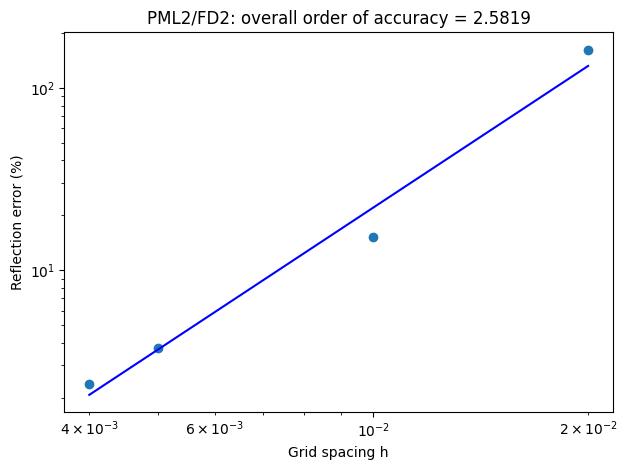

In [ ]:
# ABM = PML+EM2
# thickness = a quarter wavelength
# FD order = 2
# runtime (laptop) = 15 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = max(1,int(0.25*wavelength/h))
    abm = ph.PML("PML2", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(2))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

# Fourth-order convergence test

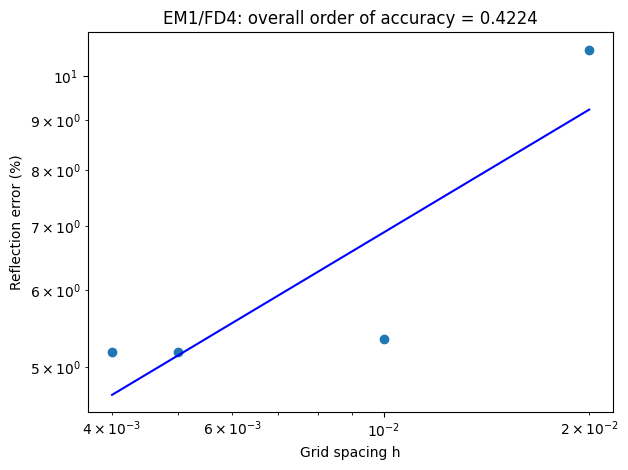

In [ ]:
# ABM = First-order Engquist-Majda ABC
# FD order = 4
# runtime (laptop) = 2m 58.2s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    abm = ph.RenLiu("EM1")
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(4))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

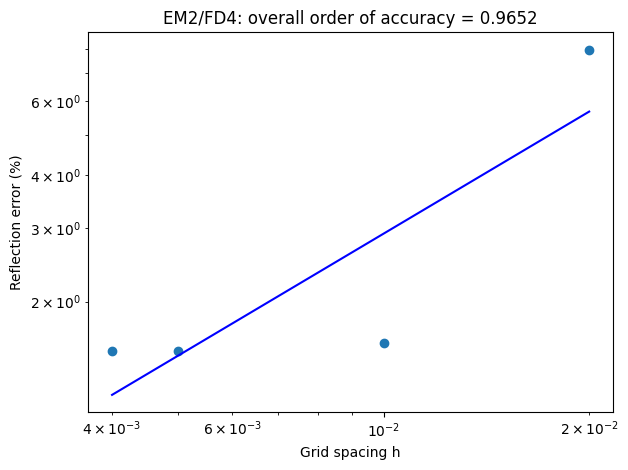

In [14]:
# ABM = Second-order Engquist-Majda ABC
# FD order = 4
# runtime (laptop) = 2m 58.2s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    abm = ph.RenLiu("EM2")
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(4))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

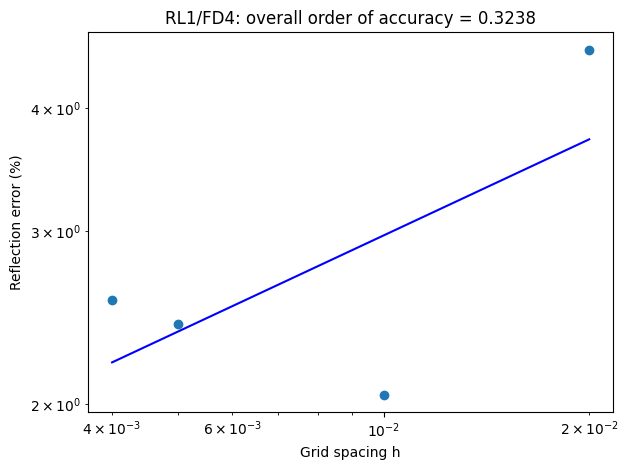

In [ ]:
# ABM = Ren-Liu hybrid ABC of first-order Engquist-Majda ABC
# thickness = one wavelength
# FD order = 4
# runtime (laptop) = 4m 44.4 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = int(wavelength/h)
    abm = ph.RenLiu("RL1", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(4))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

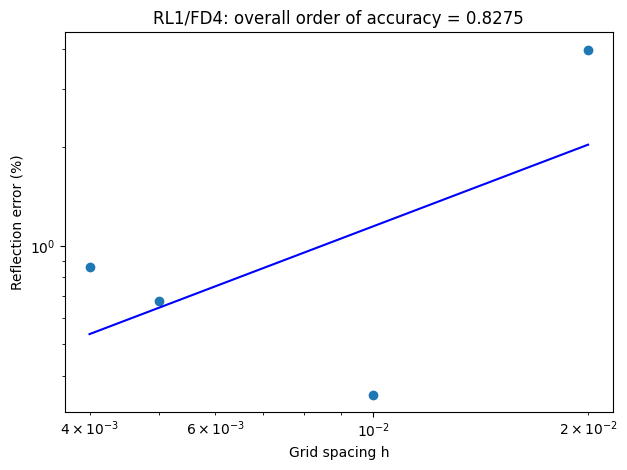

In [ ]:
# ABM = Ren-Liu hybrid ABC of first-order Engquist-Majda ABC
# thickness = two wavelengths
# FD order = 4
# runtime (laptop) = 8m 13.6 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = int(2*wavelength/h)
    abm = ph.RenLiu("RL1", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(4))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

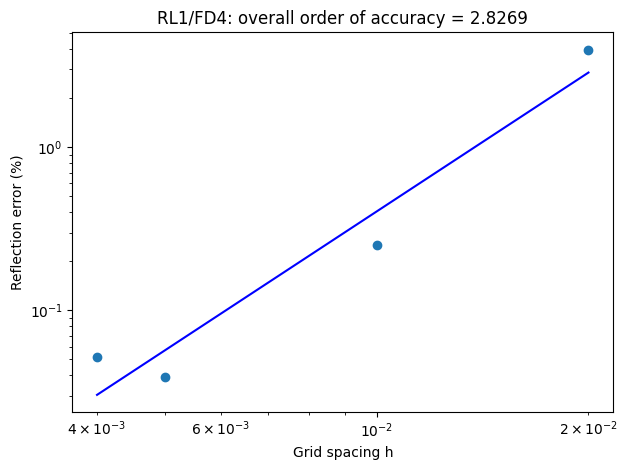

In [ ]:
# ABM = Ren-Liu hybrid ABC of first-order Engquist-Majda ABC
# thickness = four wavelengths
# FD order = 4
# runtime (ubuntu) = 8m 57.2 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = int(4*wavelength/h)
    abm = ph.RenLiu("RL1", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(4))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

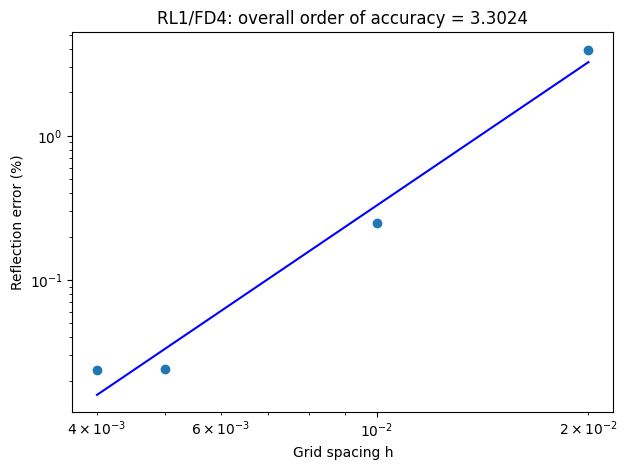

In [ ]:
# ABM = Ren-Liu hybrid ABC of first-order Engquist-Majda ABC
# thickness = 6 wavelengths
# FD order = 4
# runtime (ubuntu) = 17m 28 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = int(6*wavelength/h)
    abm = ph.RenLiu("RL1", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(4))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

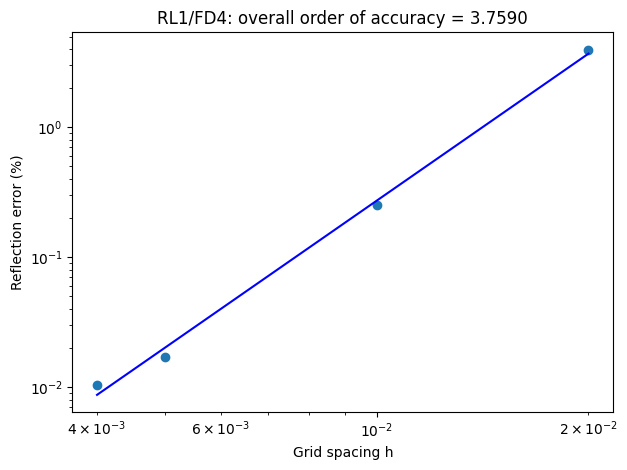

In [ ]:
# ABM = Ren-Liu hybrid ABC of first-order Engquist-Majda ABC
# thickness = 10 wavelengths
# FD order = 4
# runtime (ubuntu) = 47m 42 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = int(10*wavelength/h)
    abm = ph.RenLiu("RL1", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(4))
    ho.solve("pymumps")
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

In [2]:
# ABM = Ren-Liu hybrid ABC of first-order Engquist-Majda ABC
# thickness = 14 wavelengths
# FD order = 4
# runtime (ubuntu) = 47m 42 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = int(14*wavelength/h)
    abm = ph.RenLiu("RL1", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(4))
    ho.solve("pymumps")
    # ho.solve("nested_dissection")
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

RuntimeError: MUMPS error: -13

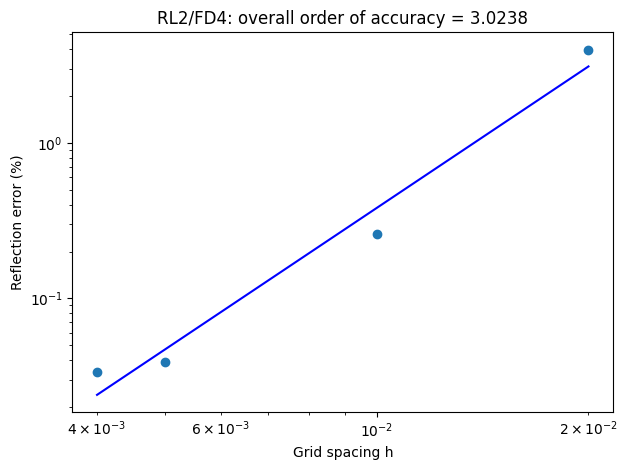

In [ ]:
# ABM = Ren-Liu hybrid ABC of second-order Engquist-Majda ABC
# thickness = 1 wavelength
# FD order = 4
# runtime (ubuntu) = 2m 37 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = int(wavelength/h)
    abm = ph.RenLiu("RL2", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(4))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

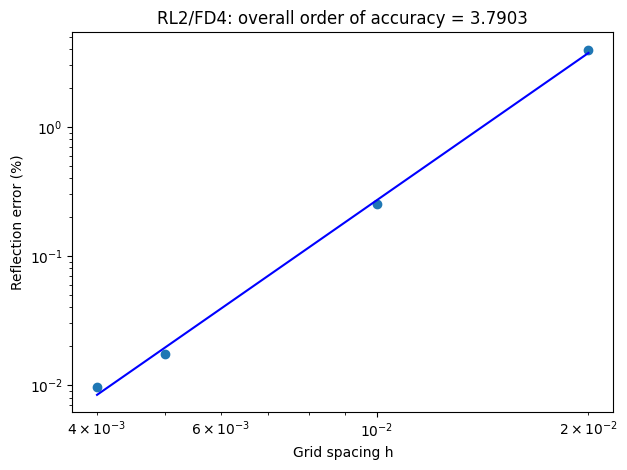

In [4]:
# ABM = Ren-Liu hybrid ABC of second-order Engquist-Majda ABC
# thickness = 2 wavelengths
# FD order = 4
# runtime (ubuntu) = 8m 57.2 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = int(2*wavelength/h)
    abm = ph.RenLiu("RL2", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(4))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

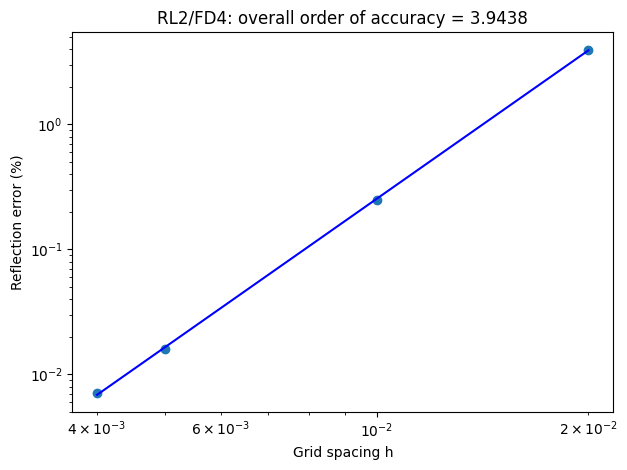

In [ ]:
# ABM = Ren-Liu hybrid ABC of second-order Engquist-Majda ABC
# thickness = 3 wavelengths
# FD order = 4
# runtime (ubuntu) = 6m 2 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = int(3*wavelength/h)
    abm = ph.RenLiu("RL2", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(4))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

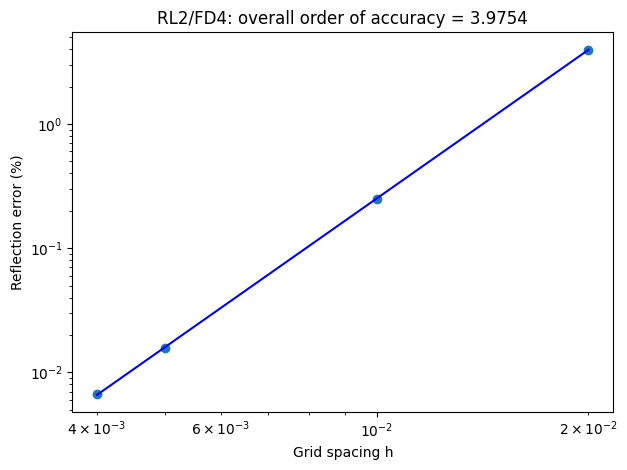

In [ ]:
# ABM = Ren-Liu hybrid ABC of second-order Engquist-Majda ABC
# thickness = 4 wavelengths
# FD order = 4
# runtime (ubuntu) = 8m 31.6 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = int(4*wavelength/h)
    abm = ph.RenLiu("RL2", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(4))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

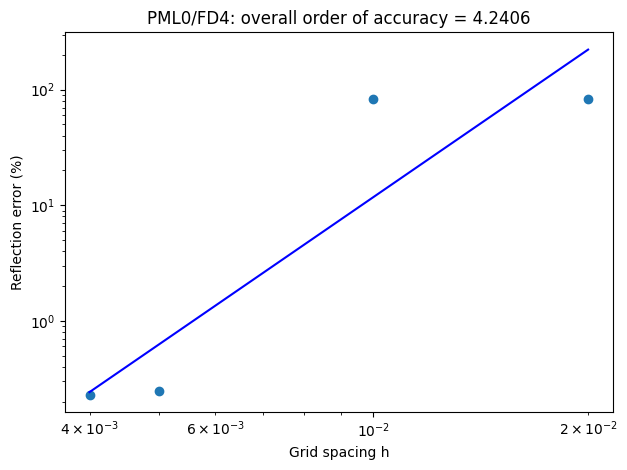

In [ ]:
# ABM = PML
# thickness = wavelength/8
# FD order = 4
# runtime (ubuntu) = 1m 41s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = max(1,int(0.125*wavelength/h))
    abm = ph.PML("PML0", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(4))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

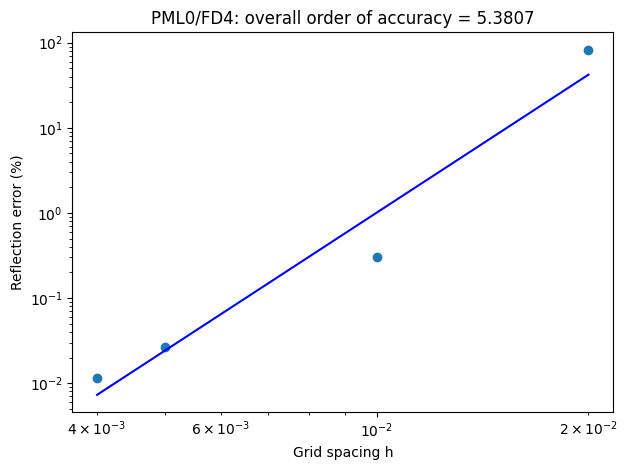

In [ ]:
# ABM = PML
# thickness = a quarter wavelength
# FD order = 4
# runtime (ubuntu) = 1m 38 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = int(0.25*wavelength/h)
    abm = ph.PML("PML0", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(4))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

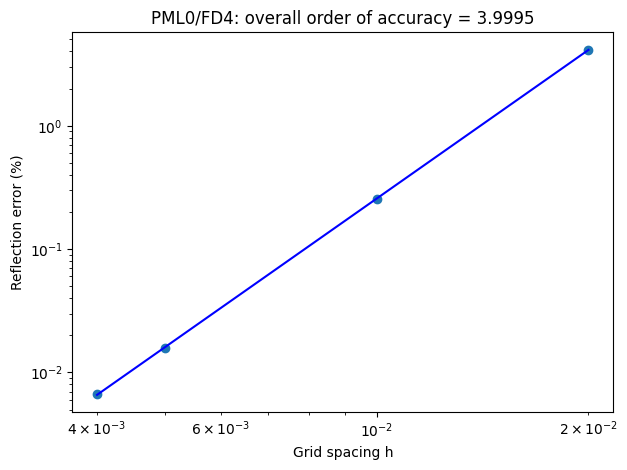

In [ ]:
# ABM = PML
# thickness = half wavelength
# FD order = 4
# runtime (ubuntu) = 2m 1.4 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = int(0.5*wavelength/h)
    abm = ph.PML("PML0", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(4))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

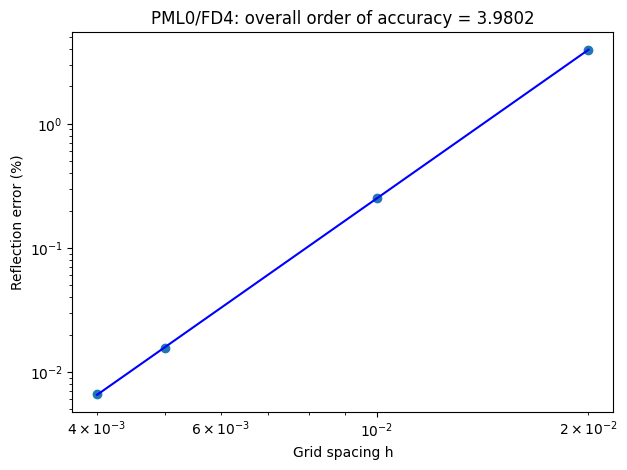

In [ ]:
# ABM = PML
# thickness = 1 wavelength
# FD order = 4
# runtime (ubuntu) = 2m 23 s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = int(wavelength/h)
    abm = ph.PML("PML0", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(4))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

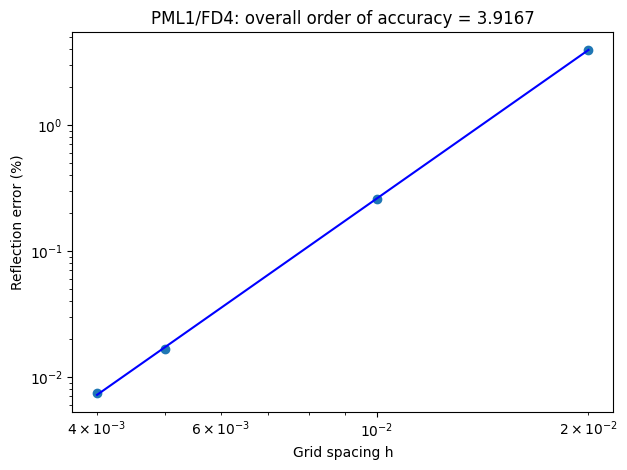

In [ ]:
# ABM = PML+EM1
# thickness = half wavelength
# FD order = 4
# runtime (ubuntu) = 2m 8s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = max(1,int(0.5*wavelength/h))
    abm = ph.PML("PML1", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(4))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

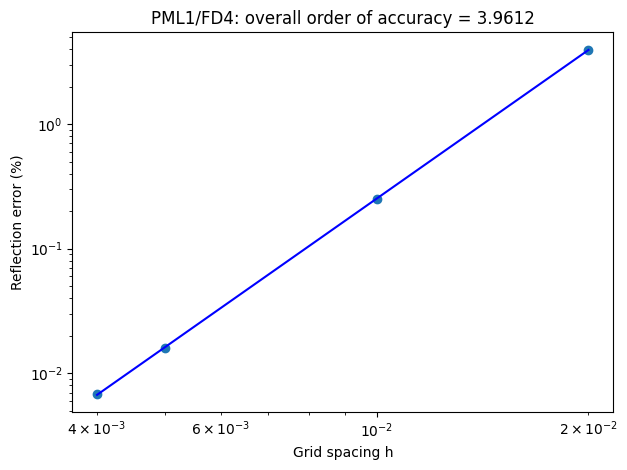

In [ ]:
# ABM = PML+EM1
# thickness = 1 wavelength
# FD order = 4
# runtime (ubuntu) = 2m 41s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = max(1,int(wavelength/h))
    abm = ph.PML("PML1", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(4))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

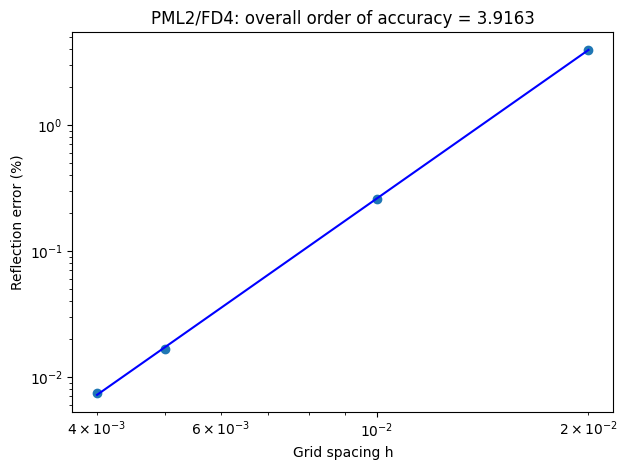

In [ ]:
# ABM = PML+EM2
# thickness = half wavelength
# FD order = 4
# runtime (ubuntu) = 1m 50s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = max(1,int(0.5*wavelength/h))
    abm = ph.PML("PML2", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(4))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

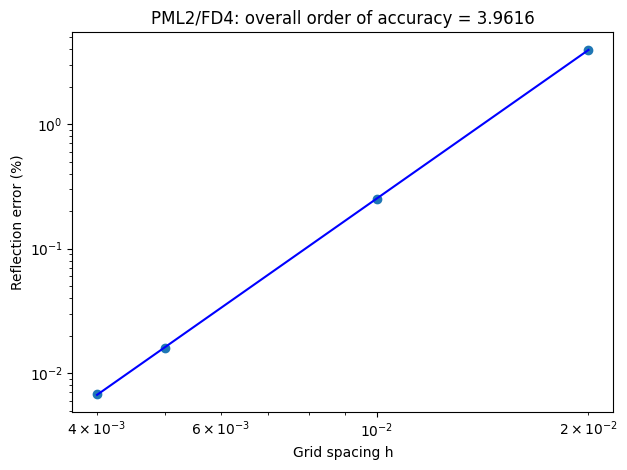

In [ ]:
# ABM = PML+EM2
# thickness = 1 wavelength
# FD order = 4
# runtime (ubuntu) = 2m 18s
err_array = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = max(1,int(wavelength/h))
    abm = ph.PML("PML2", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(4))
    ho.solve()
    err_array[i] = ho.error_norm_point_source()
loglog(h_array,err_array,'o')
p, c = np.polyfit(np.log(h_array), np.log(err_array), 1)
title(f"{ho.abm.abm}/FD{ho.fd.order}: overall order of accuracy = {p:.4f}")
log_err = p*np.log(h_array)+c
loglog(h_array,np.exp(log_err),'b')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()

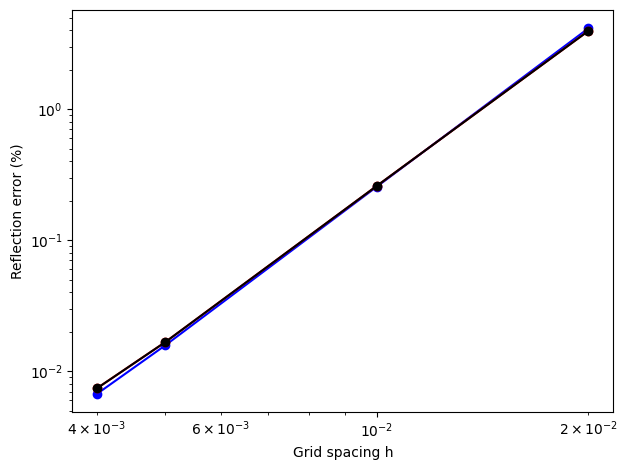

In [3]:
# Comparison of PML, PML1, and PML2
# thickness = half wavelength
# FD order = 4
# runtime (ubuntu) = 1m 36 s
err_array0 = np.zeros_like(h_array)
err_array1 = np.zeros_like(h_array)
err_array2 = np.zeros_like(h_array)
for i, h in enumerate(h_array):
    domain = ph.Domain(h=h, limits=limits)
    n = int(0.5*wavelength/h)
    abm = ph.PML("PML0", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(4))
    ho.solve("nested_dissection")
    err_array0[i] = ho.error_norm_point_source()

    abm = ph.PML("PML1", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(4))
    ho.solve("nested_dissection")
    err_array1[i] = ho.error_norm_point_source()

    abm = ph.PML("PML2", n=n)
    ho = ph.Helmholtz(domain=domain, abm=abm, source=source, fd=ph.FD(4))
    ho.solve("nested_dissection")
    err_array2[i] = ho.error_norm_point_source()
loglog(h_array,err_array0,'bo-', h_array,err_array1,'ro-', h_array,err_array2,'ko-')
xlabel('Grid spacing h')
ylabel('Reflection error (%)')
gcf().tight_layout()